In [ ]:
!pip install diffusers transformers accelerate

In [12]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt


In [ ]:
!pip show torch

Name: torch
Version: 2.10.0+cpu
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


In [ ]:
from diffusers import StableDiffusionXLPipeline, AutoencoderKL
import torch

model_id2= "stabilityai/stable-diffusion-xl-base-1.0"

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    # Load VAE separately in float32
    vae = AutoencoderKL.from_pretrained(model_id2, subfolder="vae", torch_dtype=torch.float32)
    # Load the rest of the pipeline in float16
    pipe = StableDiffusionXLPipeline.from_pretrained(model_id2, vae=vae, torch_dtype=torch.float16)
else:
    # On CPU, load everything in float32
    pipe = StableDiffusionXLPipeline.from_pretrained(model_id2, torch_dtype=torch.float32)

pipe = pipe.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [8]:
prompt= """dreamlikeart, a grungy woman with rainbow hair, travelling between dimensions, dynamic poses, happy, soft eyes and narrow chin, extreme bokeh, dainty figure, long hair straight down, torn kawaii shirt and baggy jeans"""

In [9]:
image= pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


[PROMPT] dreamlikeart, a grungy woman with rainbow hair, travelling between dimensions, dynamic poses, happy, soft eyes and narrow chin, extreme bokeh, dainty figure, long hair straight down, torn kawaii shirt and baggy jeans


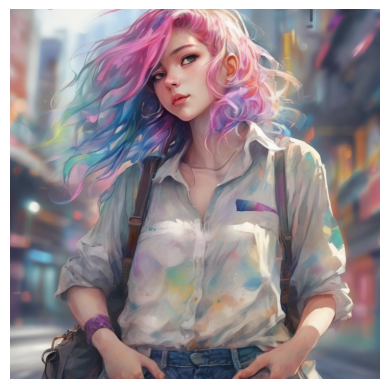

In [13]:
print("[PROMPT]", prompt)
plt.imshow(image)
plt.axis("off")
plt.show()

In [17]:
def generate_image(pipe, prompt, params):
  # Get the list of images
  images_list = pipe(prompt, **params).images

  num_images = len(images_list)
  if num_images > 1:
    fig, ax = plt.subplots(nrows=1, ncols=num_images)
    for i in range(num_images):
      ax[i].imshow(images_list[i]) # Use images_list[i] to plot each image
      ax[i].axis('off')
  else:
    # If there's only one image, images_list[0] is the PIL Image object
    fig = plt.figure()
    plt.imshow(images_list[0])
    plt.axis('off')
  plt.tight_layout()

In [15]:
 prompt= "dreamlike, beautiful girl playing the festival of colors, draped in traditional Indian attire, throwing colors"
 params={}

In [24]:
generate_image(pipe, prompt, params)

  0%|          | 0/50 [00:00<?, ?it/s]

RuntimeError: Input type (c10::Half) and bias type (float) should be the same

  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


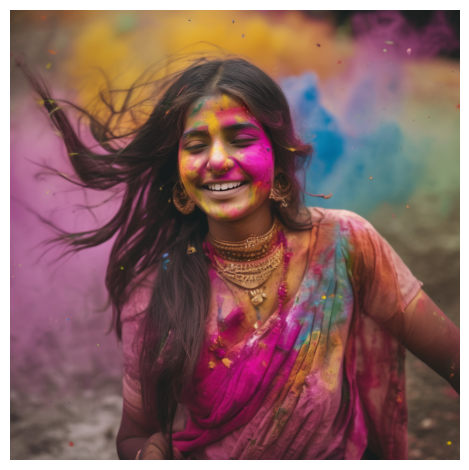

In [19]:
params= {'num_inference_steps':100}
generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


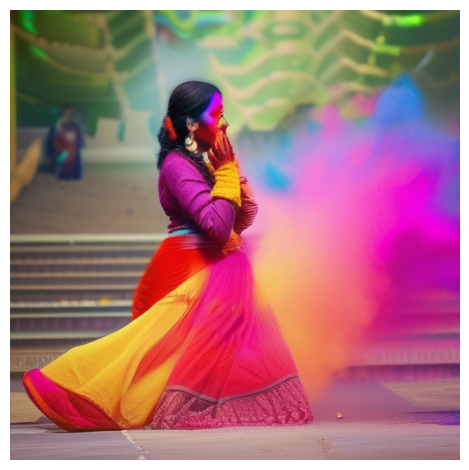

In [20]:
#height- width
params= {'num_inference_steps':100, 'height':512, 'width':512}
generate_image(pipe, prompt, params)